# Harper-Hofstadter Flux Sweep

**Model.** The Harper-Hofstadter model is a square-lattice single-particle Hamiltonian with magnetic Peierls phases. This implementation uses Landau gauge: horizontal hoppings are real and vertical hoppings carry `exp(2 pi i flux * col)`.

**Typical uses.** Magnetic-flux spectral sweeps, finite-lattice Hofstadter butterfly plots, topology-oriented toy problems, and tests for algorithms acting on complex Hermitian matrices.

**Parameters.** `n_rows` and `n_cols` set lattice size; `hopping` sets nearest-neighbor hopping strength; `flux` is flux per plaquette in units of the flux quantum; `periodic_x` and `periodic_y` control boundary wrapping.

**Useful plots.** Spectrum versus flux, density of states at fixed flux, and square-lattice graph connectivity.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from quantum_lattice_models.geometry import square_lattice_positions
from quantum_lattice_models.models import harper_hofstadter_square_lattice
from quantum_lattice_models.plotting import (
    plot_hofstadter_butterfly,
    plot_lattice_graph,
    plot_lattice_spectrum,
)

In [2]:
n_rows = 4
n_cols = 4
flux = 0.25
H = harper_hofstadter_square_lattice(n_rows=n_rows, n_cols=n_cols, hopping=1.0, flux=flux)
print("Harper-Hofstadter model")
print(f"  matrix shape: {H.shape}")
print(f"  lattice:      {n_rows} x {n_cols}")
print(f"  hopping:      {H.metadata['hopping']:.2f}")
print(f"  flux:         {H.metadata['flux']:.2f}")

Harper-Hofstadter model
  matrix shape: (16, 16)
  lattice:      4 x 4
  hopping:      1.00
  flux:         0.25


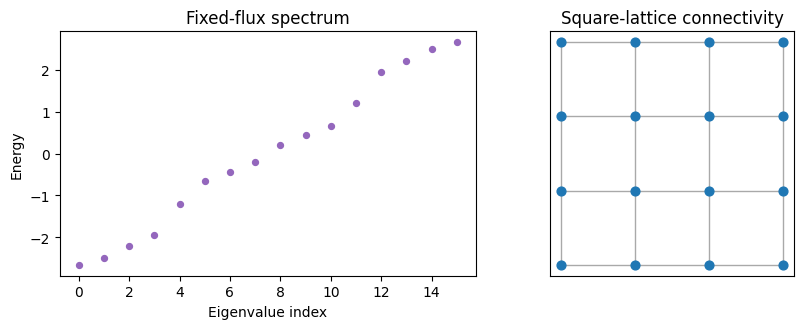

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.4))
plot_lattice_spectrum(H, ax=axes[0], s=18, color="tab:purple")
axes[0].set_title("Fixed-flux spectrum")
plot_lattice_graph(H, square_lattice_positions(n_rows, n_cols), ax=axes[1], node_size=40)
axes[1].set_title("Square-lattice connectivity")
fig.tight_layout()

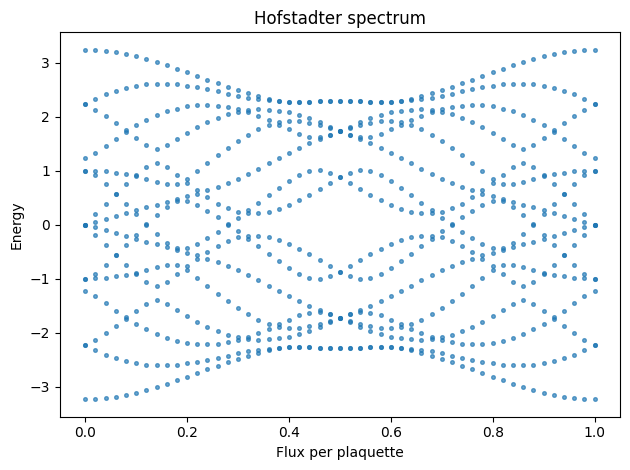

In [4]:
fluxes = np.linspace(0.0, 1.0, 51)
ax = plot_hofstadter_butterfly(
    lambda phi: harper_hofstadter_square_lattice(n_rows=n_rows, n_cols=n_cols, flux=phi),
    fluxes,
    s=7,
    color="tab:blue",
)
ax.figure.tight_layout()